# Auto-Quant Experiment Analysis

Reads `results.tsv` (event log: `commit | event | strategy_name | sharpe | max_dd | note`) and produces per-strategy timelines, cap utilization, event distributions, the Pareto frontier, and note-word frequency.

**Schema note**: In v0.4.1+, `sharpe` and `max_dd` are written by `run.py` as `robust_sharpe = min(sharpe across declared timeranges)` and `worst_dd = max(|max_dd| across timeranges)` — both per-regime worst case, not full-period numbers.

**Default data source** is the latest `versions/*/results.tsv` archive. To read an active run instead, set `RESULTS_PATH = "results.tsv"` in cell 2.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Default: latest archived run. Override RESULTS_PATH to read the active run.
def _default_results_path() -> str:
    archives = sorted(Path("versions").glob("*/results.tsv")) if Path("versions").is_dir() else []
    if archives:
        return str(archives[-1])  # highest version directory wins
    if Path("results.tsv").exists():
        return "results.tsv"
    raise FileNotFoundError("no results.tsv found in versions/ or repo root")

RESULTS_PATH = _default_results_path()

df = pd.read_csv(RESULTS_PATH, sep="\t")
df["sharpe"] = pd.to_numeric(df["sharpe"], errors="coerce")
df["max_dd"] = pd.to_numeric(df["max_dd"], errors="coerce")
df["event"] = df["event"].str.strip().str.lower()

# For fork events, strategy_name is "parent→child" — split into two columns
# so we can treat the child as the new strategy moving forward.
def _canonical(name: str) -> str:
    if isinstance(name, str) and "→" in name:
        return name.split("→", 1)[1]
    return name

df["parent"] = df["strategy_name"].map(
    lambda s: s.split("→", 1)[0] if isinstance(s, str) and "→" in s else None
)
df["strategy"] = df["strategy_name"].map(_canonical)
df = df.reset_index(drop=True)
df["round_idx"] = df.index

print(f"Source:           {RESULTS_PATH}")
print(f"Total events:     {len(df)}")
print(f"Strategies seen:  {df['strategy'].nunique()}")
df.head(8)

Source:           versions/0.4.1/results.tsv
Total events:     98
Strategies seen:  12


,commit,event,strategy_name,sharpe,max_dd,note,parent,strategy,round_idx
0,edf1687,create,AltsBollBreak,-2.3300,-45.03,r0 baseline. Bollinger-20-upper + ADX>25 + vol...,None,AltsBollBreak,0
1,edf1687,create,BNBMeanRevertSharp,0.0789,-3.10,r0 baseline. RSI<25 entry / RSI>55 exit on BNB...,None,BNBMeanRevertSharp,1
2,edf1687,create,TrendRegimeFiltered,-0.3054,-22.48,r0 baseline. 4h EMA20>EMA50 + 1d close>EMA200 ...,None,TrendRegimeFiltered,2
3,1ab2657,evolve,AltsBollBreak,-1.1800,-39.25,r1: BB-upper-single-bar → Donchian-48 sustaine...,None,AltsBollBreak,3
4,1ab2657,evolve,BNBMeanRevertSharp,-0.3800,-9.51,r1: RSI<25→<30 BACKFIRED across all 4 regimes....,None,BNBMeanRevertSharp,4
5,1ab2657,evolve,TrendRegimeFiltered,-0.3900,-23.14,r1: tighten 1d filter from `close>EMA200` to `...,None,TrendRegimeFiltered,5
6,a10a1ff,evolve,AltsBollBreak,-1.7000,-29.21,r2: add 1d close>EMA200_1d macro filter on top...,None,AltsBollBreak,6
7,a10a1ff,evolve,BNBMeanRevertSharp,0.0789,-3.10,r2: revert r1's RSI<30→<25. Numbers EXACTLY ma...,None,BNBMeanRevertSharp,7


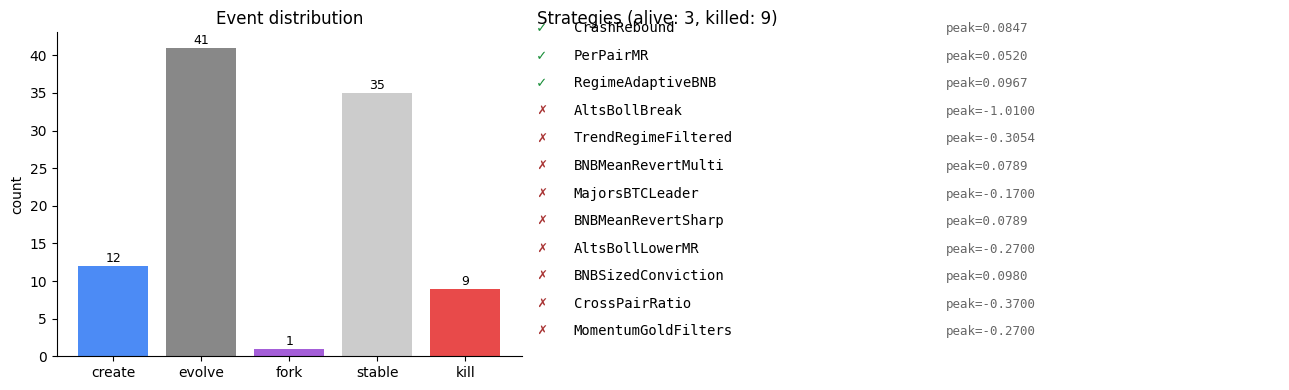

In [2]:
# Event type distribution + alive/killed sets
event_counts = df["event"].value_counts()

last_event_per = df.groupby("strategy").tail(1).set_index("strategy")
alive = last_event_per[last_event_per["event"] != "kill"].index.tolist()
dead = last_event_per[last_event_per["event"] == "kill"].index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [1, 1.6]})

colors = {"create": "#4c8bf5", "evolve": "#888888", "fork": "#a45ed8",
          "stable": "#cccccc", "kill": "#e84a4a"}
ordered = [e for e in ["create", "evolve", "fork", "stable", "kill"] if e in event_counts.index]
ax1.bar(ordered, [event_counts[e] for e in ordered],
        color=[colors[e] for e in ordered])
for i, e in enumerate(ordered):
    ax1.text(i, event_counts[e] + 0.5, str(event_counts[e]),
             ha="center", fontsize=9)
ax1.set_title("Event distribution")
ax1.set_ylabel("count")
ax1.spines[["top", "right"]].set_visible(False)

ax2.axis("off")
ax2.set_title(f"Strategies (alive: {len(alive)}, killed: {len(dead)})", loc="left")
lines = []
for s in alive:
    peak = df[df["strategy"] == s]["sharpe"].max()
    lines.append(("✓", s, peak, "#1b8f3a"))
for s in dead:
    peak = df[df["strategy"] == s]["sharpe"].max()
    lines.append(("✗", s, peak, "#a83232"))
for i, (mark, s, peak, color) in enumerate(lines):
    ax2.text(0.0, 1 - i * 0.085, mark, fontsize=11, color=color,
             transform=ax2.transAxes, family="monospace")
    ax2.text(0.05, 1 - i * 0.085, s, fontsize=10,
             transform=ax2.transAxes, family="monospace")
    if pd.notna(peak):
        ax2.text(0.55, 1 - i * 0.085, f"peak={peak:.4f}",
                 fontsize=9, color="#666", transform=ax2.transAxes,
                 family="monospace")
plt.tight_layout()
plt.show()

## Per-strategy Sharpe trajectories

Each line = one strategy's `sharpe` (robust_sharpe in v0.4.1+) over its lifetime. Markers: `○` create, `△` fork, `×` kill. Stable rounds compress into the line itself. A line ending in a red `×` means the strategy was killed at that point.

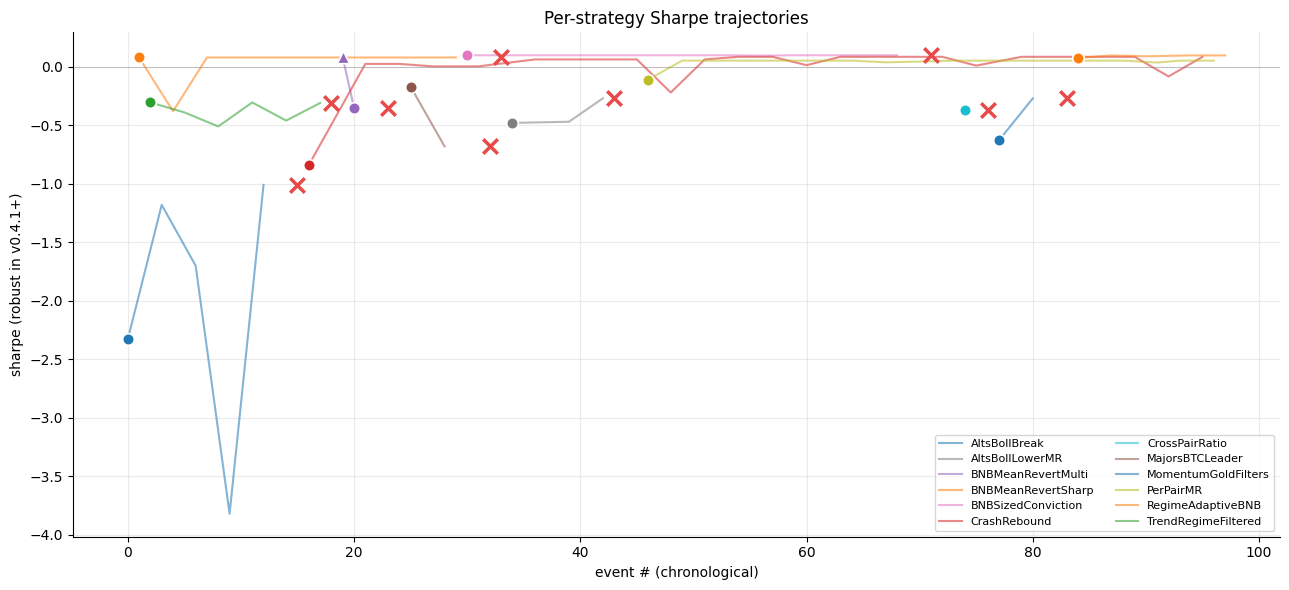

In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

cmap = plt.get_cmap("tab10")
strategies = list(df["strategy"].dropna().unique())
color_for = {s: cmap(i % 10) for i, s in enumerate(strategies)}

for name, g in df.dropna(subset=["sharpe"]).groupby("strategy"):
    g = g.sort_values("round_idx")
    c = color_for[name]
    ax.plot(g["round_idx"], g["sharpe"], alpha=0.55, color=c, linewidth=1.5, label=name)
    creates = g[g["event"] == "create"]
    forks = g[g["event"] == "fork"]
    ax.scatter(creates["round_idx"], creates["sharpe"], marker="o", s=70, color=c, edgecolor="white", linewidth=1.2, zorder=3)
    ax.scatter(forks["round_idx"], forks["sharpe"], marker="^", s=80, color=c, edgecolor="white", linewidth=1.2, zorder=3)

for name, g in df.groupby("strategy"):
    last = g.iloc[-1]
    if last["event"] == "kill":
        prior = g[g["sharpe"].notna()]
        y = prior["sharpe"].iloc[-1] if len(prior) else 0
        ax.scatter([last["round_idx"]], [y], marker="x", c="#e84a4a", s=110, linewidths=2.5, zorder=4)

ax.axhline(0, color="gray", linewidth=0.6, alpha=0.5)
ax.set_xlabel("event # (chronological)")
ax.set_ylabel("sharpe (robust in v0.4.1+)")
ax.set_title("Per-strategy Sharpe trajectories")
ax.legend(loc="best", fontsize=8, ncol=2)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Pareto frontier (sharpe vs drawdown)

Each dot is one event row that produced a backtest result. Higher and to the right is better (sharpe up, smaller drawdown). The dashed line traces the Pareto frontier of *kept* strategies — candidates that no other run strictly dominates.

v0.4.1's `pareto_dominated_by` gate fires by computing exactly this relation against historical rows.

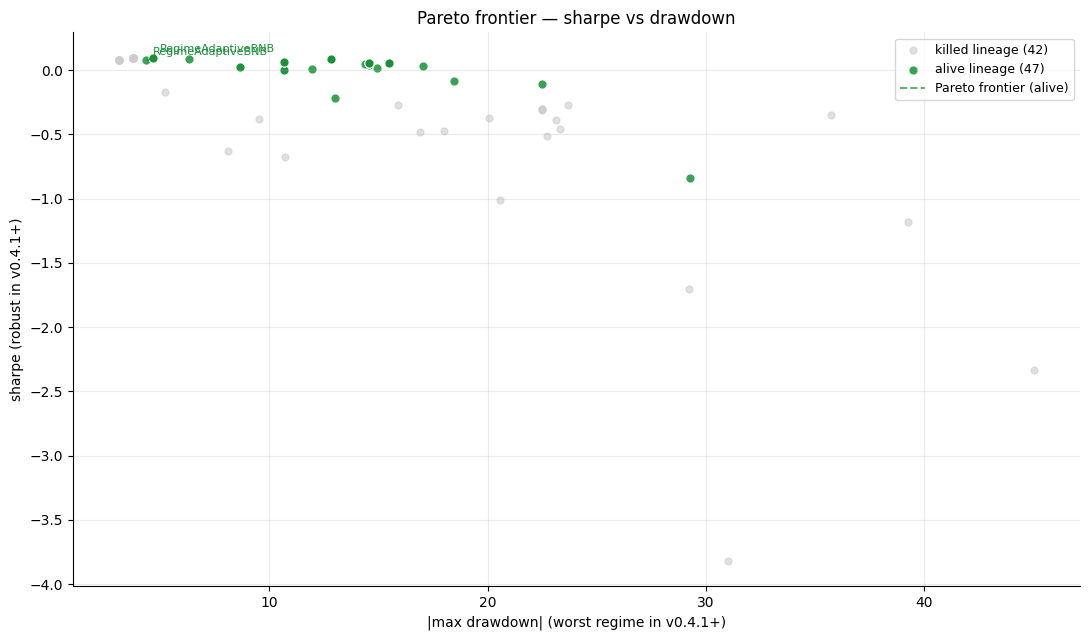

In [4]:
scored = df.dropna(subset=["sharpe", "max_dd"]).copy()
scored["abs_dd"] = scored["max_dd"].abs()
scored["killed_eventually"] = scored["strategy"].isin(dead)

fig, ax = plt.subplots(figsize=(11, 6.5))

alive_pts = scored[~scored["killed_eventually"]]
killed_pts = scored[scored["killed_eventually"]]

ax.scatter(killed_pts["abs_dd"], killed_pts["sharpe"],
           c="#cccccc", s=24, alpha=0.6, label=f"killed lineage ({len(killed_pts)})")
ax.scatter(alive_pts["abs_dd"], alive_pts["sharpe"],
           c="#1b8f3a", s=42, alpha=0.85, edgecolor="white", linewidth=0.6,
           label=f"alive lineage ({len(alive_pts)})")

# Pareto frontier of alive points: sort by abs_dd ascending, take points
# where sharpe is a new running max
frontier_pts = alive_pts.sort_values("abs_dd")
running_max = -np.inf
frontier_keep = []
for _, row in frontier_pts.iterrows():
    if row["sharpe"] > running_max:
        running_max = row["sharpe"]
        frontier_keep.append(row)
frontier = pd.DataFrame(frontier_keep)

if len(frontier) >= 2:
    ax.plot(frontier["abs_dd"], frontier["sharpe"],
            "--", color="#1b8f3a", linewidth=1.4, alpha=0.7,
            label="Pareto frontier (alive)")

for _, row in frontier.iterrows():
    ax.annotate(row["strategy"], (row["abs_dd"], row["sharpe"]),
                xytext=(5, 4), textcoords="offset points",
                fontsize=8, color="#1b8f3a")

ax.set_xlabel("|max drawdown| (worst regime in v0.4.1+)")
ax.set_ylabel("sharpe (robust in v0.4.1+)")
ax.set_title("Pareto frontier — sharpe vs drawdown")
ax.legend(loc="best", fontsize=9)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Active strategy count over time

Hard cap is 3. Count should mostly sit at 3 (slots full) and dip when a kill happens without immediate replacement. Sustained dips below 3 mean the agent isn't using its budget — either exploring cautiously or running out of ideas.

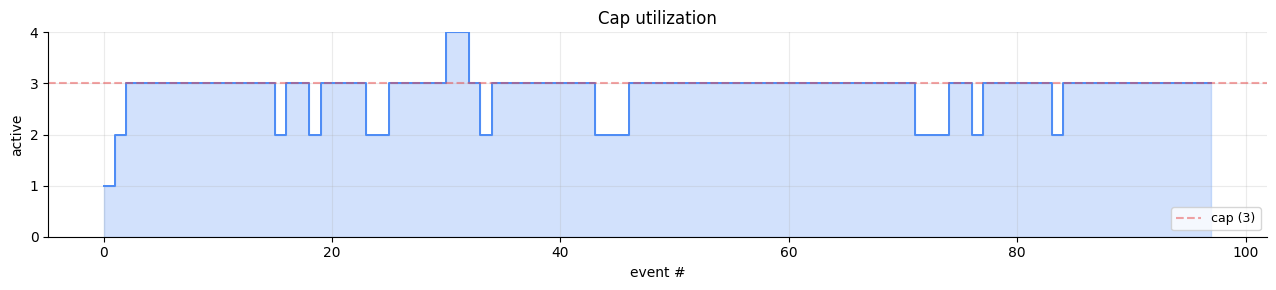

In [5]:
active = set()
counts = []
for _, row in df.iterrows():
    name = row["strategy"]
    evt = row["event"]
    if evt == "create" or evt == "fork":
        active.add(name)
    elif evt == "kill":
        active.discard(name)
    counts.append(len(active))
df["active_count"] = counts

fig, ax = plt.subplots(figsize=(13, 3))
ax.fill_between(df["round_idx"], 0, df["active_count"],
                step="post", alpha=0.25, color="#4c8bf5")
ax.plot(df["round_idx"], df["active_count"], drawstyle="steps-post",
        color="#4c8bf5", linewidth=1.4)
ax.axhline(3, color="#e84a4a", linestyle="--", alpha=0.5, label="cap (3)")
ax.set_xlabel("event #")
ax.set_ylabel("active")
ax.set_title("Cap utilization")
ax.set_ylim(0, 4)
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Note word frequency

Rough proxy for the paradigms, indicators, and failure modes the agent thought about during this run. Skim the top 30 — if you see only one paradigm family dominating, anchoring is creeping in.

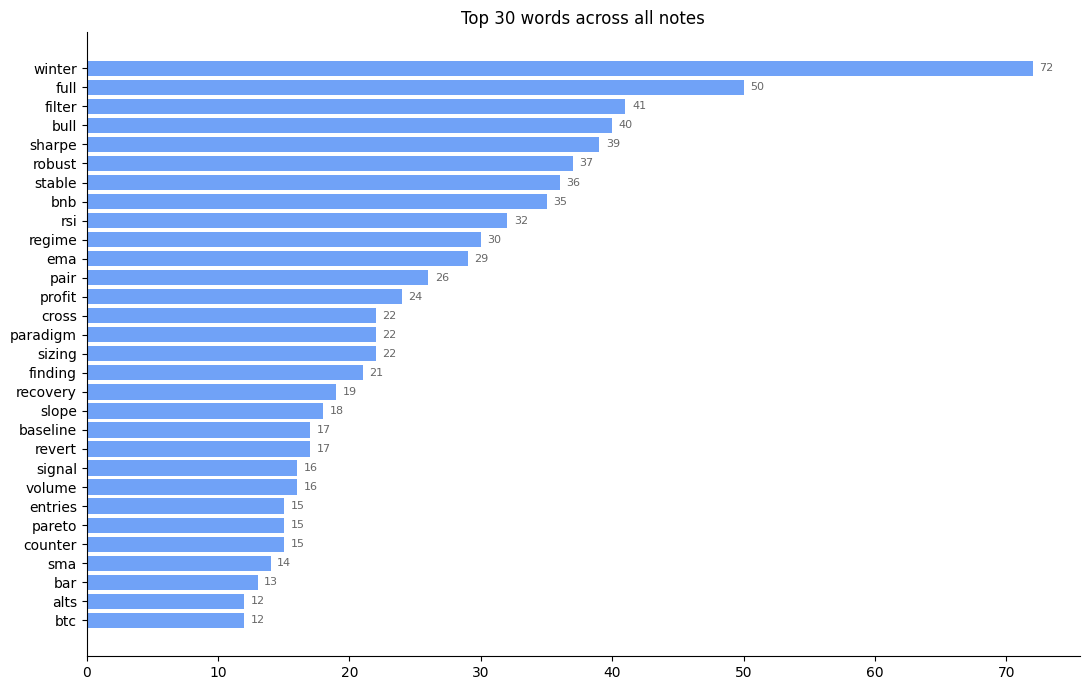

In [6]:
from collections import Counter
import re

text = " ".join(df["note"].dropna().astype(str).str.lower().tolist())
words = re.findall(r"[a-z]{3,}", text)
stop = {
    "the", "and", "for", "with", "this", "that", "from", "was", "too",
    "add", "added", "use", "using", "but", "all", "not", "has", "have",
    "trade", "trades", "run", "ran", "same", "than", "more", "less",
    "still", "then", "one", "two", "new", "old", "now", "are", "its",
    "out", "per", "via", "each", "just", "only", "can", "any", "into",
    "both", "which", "when", "will", "also", "see", "between", "under",
}
top = Counter(w for w in words if w not in stop).most_common(30)

fig, ax = plt.subplots(figsize=(11, 7))
labels = [w for w, _ in reversed(top)]
values = [c for _, c in reversed(top)]
ax.barh(labels, values, color="#4c8bf5", alpha=0.8)
for i, v in enumerate(values):
    ax.text(v + 0.5, i, str(v), va="center", fontsize=8, color="#666")
ax.set_title("Top 30 words across all notes")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()